In [22]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sklearn as sk
from scipy.optimize import minimize
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.base import clone

In [23]:
rodar_rn = True
resetar_banco = True

In [24]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_rn\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")

A pasta já está vazia.


In [25]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phase = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

columns = data[0].columns
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']

In [26]:
bins   = [0, 50, 100, 150, 200, 300, np.inf]
labels = ['0–50', '50–100', '100–150', '150–200', '200–300', '300+']
for i in range(len(data)):
        data[i]['AmplitudeRange'] = pd.cut(data[i]['AmplitudeSample(4)'], bins=bins, labels=labels, right=False)
        peak_energy = (data[i].groupby('AmplitudeRange', observed=True)[columns].max().max(axis=1))

        for faixa in peak_energy.index:

                idx = data[i]['AmplitudeRange'] == faixa

                data[i].loc[idx, columns] = (data[i].loc[idx, columns] / peak_energy[faixa])
for i in range(4):
    data[i]['phases'] = phase[i].values

In [35]:
columns = data[0].columns
data[0]

,sample(0),sample(1),sample(2),sample(3),sample(4),sample(5),sample(6),AmplitudeSample(4),AmplitudeRange,phases
0,0.075185,0.053778,0.037676,0.034644,0.030581,0.031586,0.031266,0.000000,0–50,0.0
1,0.053778,0.037676,0.034644,0.030581,0.031586,0.031266,0.032563,0.000000,0–50,0.0
2,0.037676,0.034644,0.030581,0.031586,0.031266,0.032563,0.030827,0.000000,0–50,0.0
3,0.034644,0.030581,0.031586,0.031266,0.032563,0.030827,0.033604,0.000000,0–50,0.0
4,0.030581,0.031586,0.031266,0.032563,0.030827,0.033604,0.034342,0.000000,0–50,0.0
...,...,...,...,...,...,...,...,...,...,...
69989,0.178520,0.087768,0.045823,0.038910,0.139100,0.369464,0.271968,0.000000,0–50,0.0
69990,0.087768,0.045823,0.038910,0.139100,0.369464,0.271968,0.101052,0.000000,0–50,0.0
69991,0.045823,0.038910,0.139100,0.369464,0.271968,0.101052,0.049849,0.347001,300+,-5.0
69992,0.038910,0.139100,0.369464,0.271968,0.101052,0.049849,0.035437,0.000000,0–50,0.0


In [28]:
#Rede Neural
def run_model(X, y, occ):

    # Modelo 
    base_model = MLPRegressor(
        hidden_layer_sizes=(20,10,5),
        activation='tanh',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    

    # Divisão treino e teste (80%/20%)
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
 
    model = clone(base_model)

    #Treino
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X)

    #Curva de aprendizado 
    plt.figure(figsize=(8,5))
    plt.plot(model.loss_curve_)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title(f'Curva de aprendizado - OCC {occ}')
    plt.grid(True)
    plt.show()

    return y_pred


In [29]:
def save_rn(occ, phase, amplitude_data, ns_list, amplitude_range):
    path = f'.\\tests_rn\\results\\rn_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({                    

            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'TrueAmplitude': amplitude_data,
            'AmplitudeRange': amplitude_range
        })
        
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'TrueAmplitude': amplitude_data,
            'AmplitudeRange': amplitude_range
        })

    df.to_csv(f'.\\tests_rn\\results\\rn_{occ}.csv', index=False)

In [30]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_rn:
        k = 0
        for i in range(4):
            samples_data = np.array(data[i][columns[0:7]])
            amplitude_data = np.array(data[i][columns[7]])
            range_data = np.array(data[i][columns[8]])
            phases_data = np.array(data[i][columns[9]])

            sample4 = run_model(samples_data, phases_data, occ_name[i])
            save_rn(occ_name[i], phases_data, amplitude_data, sample4, range_data)
            k +=1
            print(f'Occupancy {occ_name[i][3:]} done, lacking {4 - k} combinations')

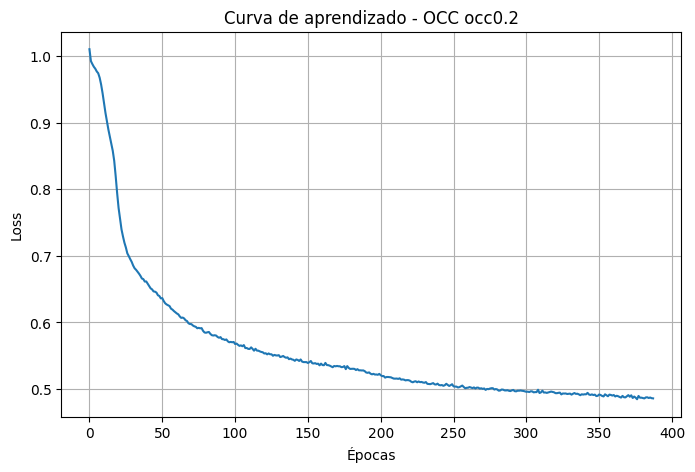

Occupancy 0.2 done, lacking 3 combinations


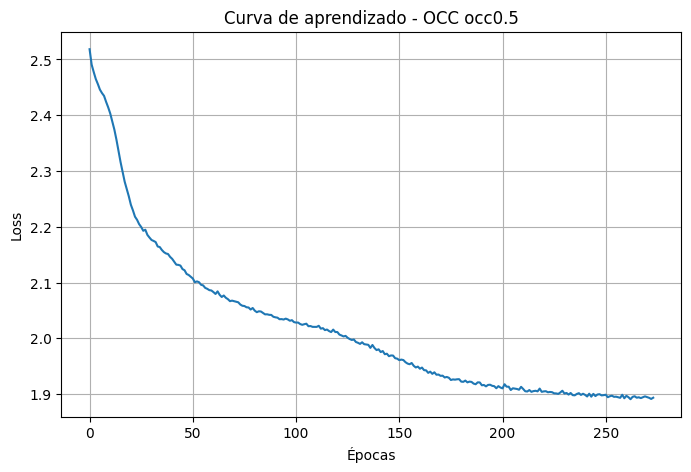

Occupancy 0.5 done, lacking 2 combinations


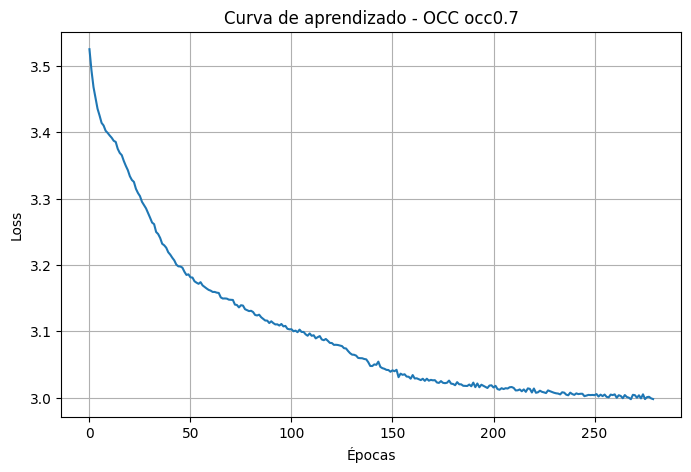

Occupancy 0.7 done, lacking 1 combinations


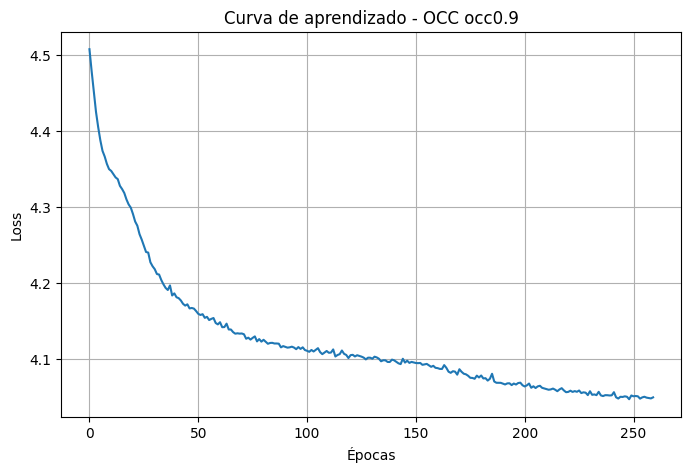

Occupancy 0.9 done, lacking 0 combinations


In [31]:
run_algorithm(data)

In [32]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_rn\results\rn_occ0.2.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.5.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.7.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.9.csv'),
    ]
    return resultados

Mean error for occupancy occ0.2: 0.024242045813716074
Std error for occupancy occ0.2: 0.9833815404806054


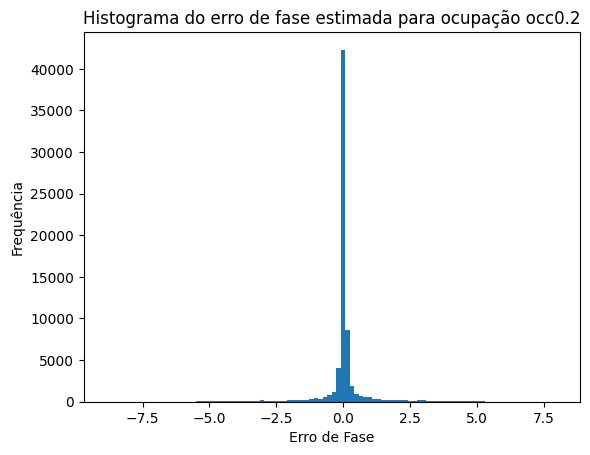

Mean error for occupancy occ0.5: -0.0772370575402077
Std error for occupancy occ0.5: 1.946676862695179


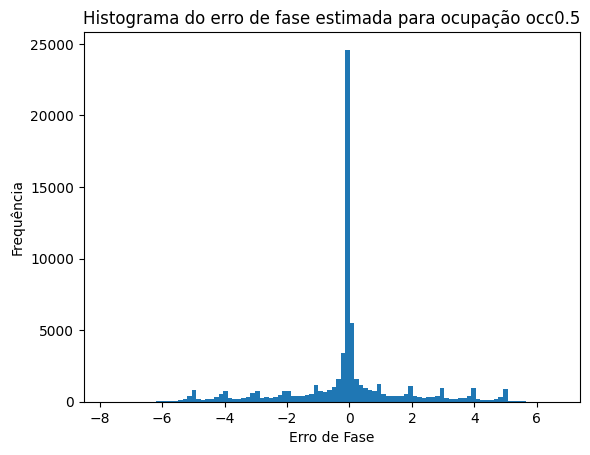

Mean error for occupancy occ0.7: 0.03019045852495477
Std error for occupancy occ0.7: 2.4458066764325905


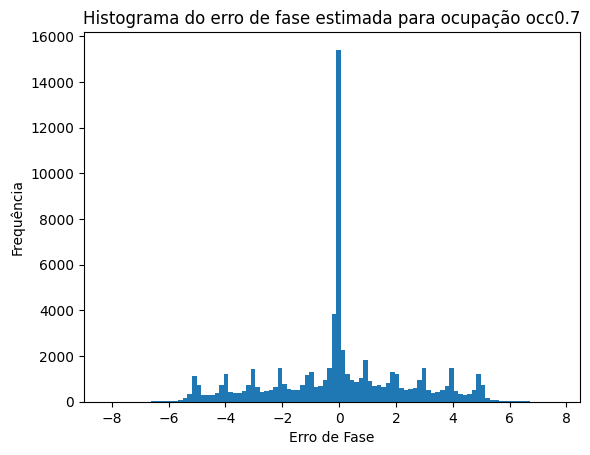

Mean error for occupancy occ0.9: -0.030618530652095223
Std error for occupancy occ0.9: 2.8432557014908313


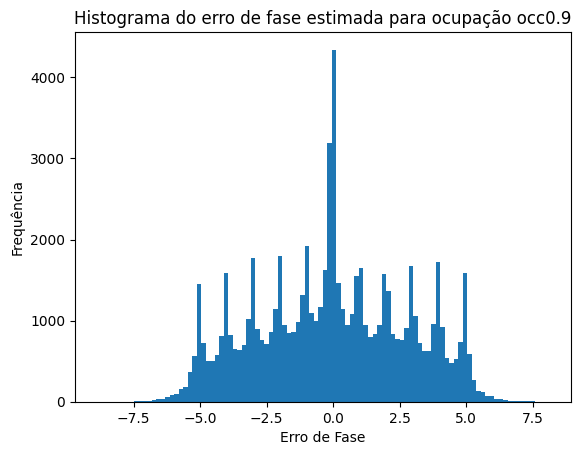

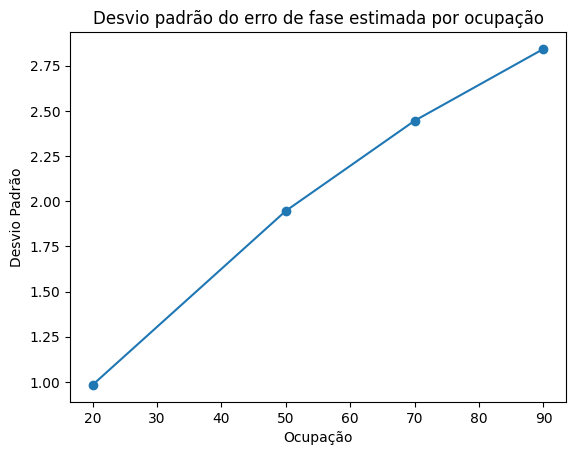

In [33]:
df = load_results()

std_errors = []
occ = [20, 50, 70, 90]

for i in range(len(df)):
    phase_error = df[i]['TruePhase'] - df[i]['PhaseEstimada']
    std_errors.append(np.std(phase_error))

    print(f'Mean error for occupancy {occ_name[i]}: {np.mean(phase_error)}')
    print(f'Std error for occupancy {occ_name[i]}: {np.std(phase_error)}')

    plt.hist(phase_error, bins=100)
    plt.title(f'Histograma do erro de fase estimada para ocupação {occ_name[i]}')
    plt.xlabel('Erro de Fase')
    plt.ylabel('Frequência')
    plt.show()
    
plt.plot(occ, std_errors, marker='o')
plt.title('Desvio padrão do erro de fase estimada por ocupação')
plt.xlabel('Ocupação')
plt.ylabel('Desvio Padrão')
plt.show()

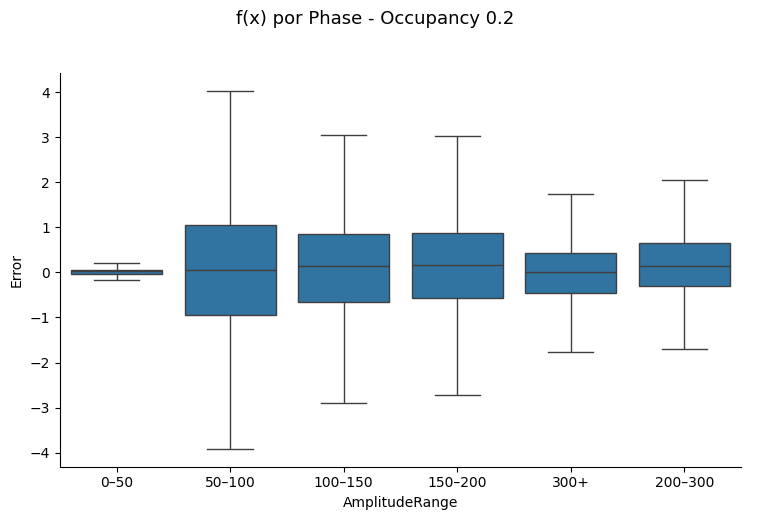

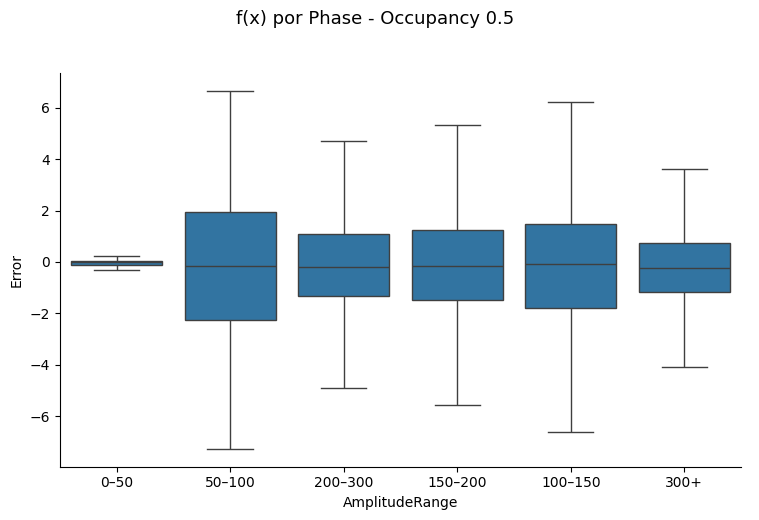

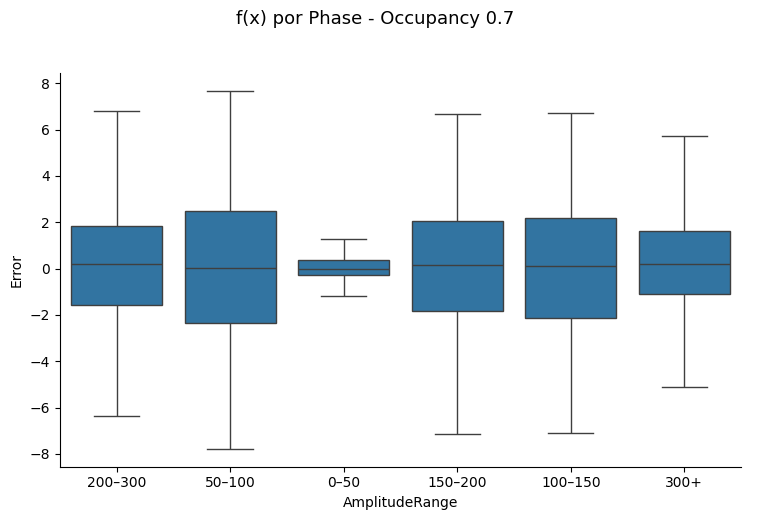

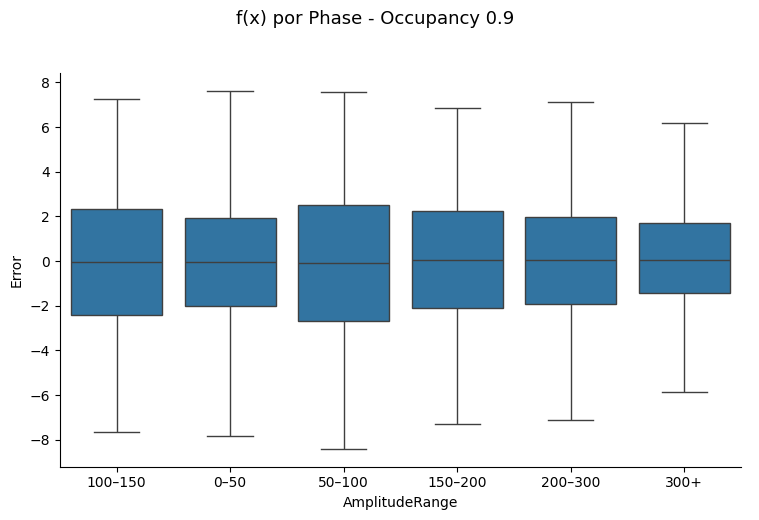

In [34]:
#faixa [0-10, 10-50, 50-100, 100-200, 200-500, 500+]
df = load_results()

for i in range(len(df)):    
    # Cria a coluna de Erro para facilitar o plot
    df[i]['Error'] = df[i]['TruePhase'] - df[i]['PhaseEstimada']

    # plt.figure(figsize=(10, 6)) <-- Você pode remover esta linha

    g = sns.catplot(
        data=df[i],          # <-- CORRIGIDO: Passando o DataFrame da iteração atual
        x='AmplitudeRange',
        y='Error',           # <-- CORRIGIDO: Usando a nova coluna criada
        kind='box',
        height=5,
        aspect=1.5,
        sharey=False,
        showfliers=False
    )

    g.set_axis_labels('AmplitudeRange', 'Error')
    g.set_titles(col_template='E: {col_name}')
    
    g.fig.suptitle(
        f'f(x) por Phase - Occupancy {occ_name[i][3:]}',
        y=1.03, fontsize=13
    )
    
    plt.tight_layout()
    plt.show()